# EDA, Análisis exploratorio gastos personales


EDA de más de N movimientos bancarios: categorización automática de gastos, análisis mensual por categoría e identificación de patrones de consumo.

## Pregunta de negocio:

* ¿Cómo puedo optimizar mi estructura de gastos para aumentar mi ahorro mensual sin reducir en exceso mi calidad de vida?

### Subpreguntas

1. ¿Qué porcentaje de mis ingresos se va a cada categoría de gasto y cómo ha evolucionado mes a mes?
2. ¿Hay meses con el mismo nivel de ingresos pero distintos niveles de saldo final? ¿A qué categorías se debe la diferencia?
3. ¿Hay meses con ‘picos’ de gasto que ponen en riesgo mantener un saldo mínimo de seguridad?

### Parte predictiva

1. Dado mi historial de ingresos y gastos por categoría, ¿cuál es mi gasto y ahorro esperados el próximo mes si no cambio nada?
2. ¿Qué efecto tendría reducir un X % el gasto en determinadas categorías sobre mi ahorro esperado?

### Importaciones de librerias

In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import calendar  # usado para obtener nombres de meses ordenados de forma fiable


### Configuración personalizada
Para darle entidad al proyecto

In [2]:
empresa_colors = ["#003f5c", "#1e829b", "#7b26bc"]

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=empresa_colors)
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.titleweight'] = "bold"




### Carga de datos e Información del dataset

In [3]:
#Forma mas robusta de poder obtener la ruta de los datos, asi puede abrir el archivo en diferentes ordenadores. 

import os
from pathlib import Path

try:
    # Obtener ruta del proyecto (raíz) de forma robusta
    # Esta ruta funciona sin importar desde dónde se ejecute el notebook
    project_root = Path(__file__).parent.parent if '__file__' in dir() else Path.cwd().parent
    datos = project_root / "data" / "raw" / "gastos_personales_2024.csv"

    print(f"📂 Ruta del proyecto: {project_root}")
    print(f"📄 Buscando CSV en: {datos}")
    
    # Validar que el archivo existe
    if not datos.exists():
        raise FileNotFoundError(f"❌ No se encontró el CSV en: {datos}")
    print(f"✅ CSV encontrado")
    
except FileNotFoundError as e:
    print(f"Error: {e}")
    raise
except Exception as e:
    print(f"Error inesperado al buscar el archivo: {e}")
    raise


📂 Ruta del proyecto: c:\Users\maxim\Proyectos\analisis_gastos_personales
📄 Buscando CSV en: c:\Users\maxim\Proyectos\analisis_gastos_personales\data\raw\gastos_personales_2024.csv
✅ CSV encontrado


In [4]:
from src.iniciar_dataframe import informacion_df

# Función propia para analizar el dataframe. De forma rápida y sencilla, arroja todos los datos necesarios
df = informacion_df(str(datos))


▶ Head (5 filas):


,fecha,tipo_movimiento,categoria,importe_eur,saldo_post_movimiento,descripcion,canal
0,2024-01-01,Ingreso,Salario,2374.51,4874.51,Nómina mensual,Transferencia
1,2024-01-01,Gasto,Transporte,-31.18,4843.32,Pago con tarjeta,Tarjeta
2,2024-01-02,Gasto,Alimentación,-58.44,4784.89,Pago con tarjeta,Tarjeta
3,2024-01-03,Gasto,Transporte,-8.37,4776.52,Pago con tarjeta,Tarjeta
4,2024-01-03,Gasto,Alimentación,-35.29,4741.23,Pago con tarjeta,Tarjeta



▶ Info del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   fecha                  582 non-null    str    
 1   tipo_movimiento        582 non-null    str    
 2   categoria              582 non-null    str    
 3   importe_eur            582 non-null    float64
 4   saldo_post_movimiento  582 non-null    float64
 5   descripcion            582 non-null    str    
 6   canal                  582 non-null    str    
dtypes: float64(2), str(5)
memory usage: 32.0 KB

▶ Dimensiones (shape):
(582, 7)

▶ Columnas:
['fecha', 'tipo_movimiento', 'categoria', 'importe_eur', 'saldo_post_movimiento', 'descripcion', 'canal']

▶ Descripción estadística (describe numérico):


,importe_eur,saldo_post_movimiento
count,582.000000,582.000000
mean,-7.873660,-267.471684
std,366.015027,1767.677453
min,-1033.920000,-3159.600000
25%,-50.307500,-1951.422500
50%,-35.770000,-317.070000
75%,-21.582500,1127.265000
max,2442.580000,4874.510000



▶ Tipos de datos:
fecha                        str
tipo_movimiento              str
categoria                    str
importe_eur              float64
saldo_post_movimiento    float64
descripcion                  str
canal                        str
dtype: object


### Limpieza de datos

In [5]:
#Sumatoria de datos nulos
valores_nulos = df.isnull().sum()

print(f"""Se registrados estos valores nulos: 
{valores_nulos}""")


Se registrados estos valores nulos: 
fecha                    0
tipo_movimiento          0
categoria                0
importe_eur              0
saldo_post_movimiento    0
descripcion              0
canal                    0
dtype: int64


No se registran datos nulos

In [6]:
#sumatoria de registros duplicados
registros_duplicados = df.duplicated().sum()
print(f'Regristros duplicados: {registros_duplicados}')

Regristros duplicados: 0


No se registran datos duplicados.

### Transformación de datos

In [7]:
df["fecha"] = pd.to_datetime(df["fecha"])

In [8]:
# Cambio: usar month_name() en lugar de strftime('%B') para mayor consistencia
# Razón: month_name() devuelve el nombre del mes de forma directa y permite
# luego usar la lista de meses de 'calendar' para ordenar sin mismatch de locales.
df["mes"] = df["fecha"].dt.month_name()

meses_ordenados = list(calendar.month_name[1:])
df["mes"] = pd.Categorical(df["mes"], categories=meses_ordenados, ordered=True)


In [9]:
df["dia"] = df["fecha"].dt.strftime("%A")
df["dia"]

0         Monday
1         Monday
2        Tuesday
3      Wednesday
4      Wednesday
         ...    
577       Sunday
578       Sunday
579       Monday
580      Tuesday
581      Tuesday
Name: dia, Length: 582, dtype: str

In [10]:
#redondeamos el saldo post movimiento en 2 decimales por mas comodidad
df["saldo_post_movimiento"] = df["saldo_post_movimiento"].round(2)

In [11]:
#funcion que agrega una columna de alerta, donde si el sueldo esta por debajo de -100, avisa que es saldo negativo
df["alerta"] = df["saldo_post_movimiento"].apply(lambda x: "Saldo negativo" if x < 0 else None)

In [12]:
from src.funciones import tipo_gasto
df["tipo_gasto"] = df["categoria"].apply(tipo_gasto)
df

,fecha,tipo_movimiento,categoria,importe_eur,saldo_post_movimiento,descripcion,canal,mes,dia,alerta,tipo_gasto
0,2024-01-01,Ingreso,Salario,2374.51,4874.51,Nómina mensual,Transferencia,January,Monday,NaN,ingreso de dinero
1,2024-01-01,Gasto,Transporte,-31.18,4843.32,Pago con tarjeta,Tarjeta,January,Monday,NaN,gasto recurrente
2,2024-01-02,Gasto,Alimentación,-58.44,4784.89,Pago con tarjeta,Tarjeta,January,Tuesday,NaN,gasto recurrente
3,2024-01-03,Gasto,Transporte,-8.37,4776.52,Pago con tarjeta,Tarjeta,January,Wednesday,NaN,gasto recurrente
4,2024-01-03,Gasto,Alimentación,-35.29,4741.23,Pago con tarjeta,Tarjeta,January,Wednesday,NaN,gasto recurrente
...,...,...,...,...,...,...,...,...,...,...,...
577,2024-12-29,Gasto,Alimentación,-20.50,-2343.79,Pago con tarjeta,Tarjeta,December,Sunday,Saldo negativo,gasto recurrente
578,2024-12-29,Ingreso,Ingreso extra,390.89,-1952.90,Ingreso puntual,Transferencia,December,Sunday,Saldo negativo,ingreso de dinero
579,2024-12-30,Gasto,Alimentación,-32.80,-1985.70,Pago con tarjeta,Tarjeta,December,Monday,Saldo negativo,gasto recurrente
580,2024-12-31,Gasto,Transporte,-50.63,-2036.32,Pago con tarjeta,Tarjeta,December,Tuesday,Saldo negativo,gasto recurrente


### Análisis Variantes numéricas

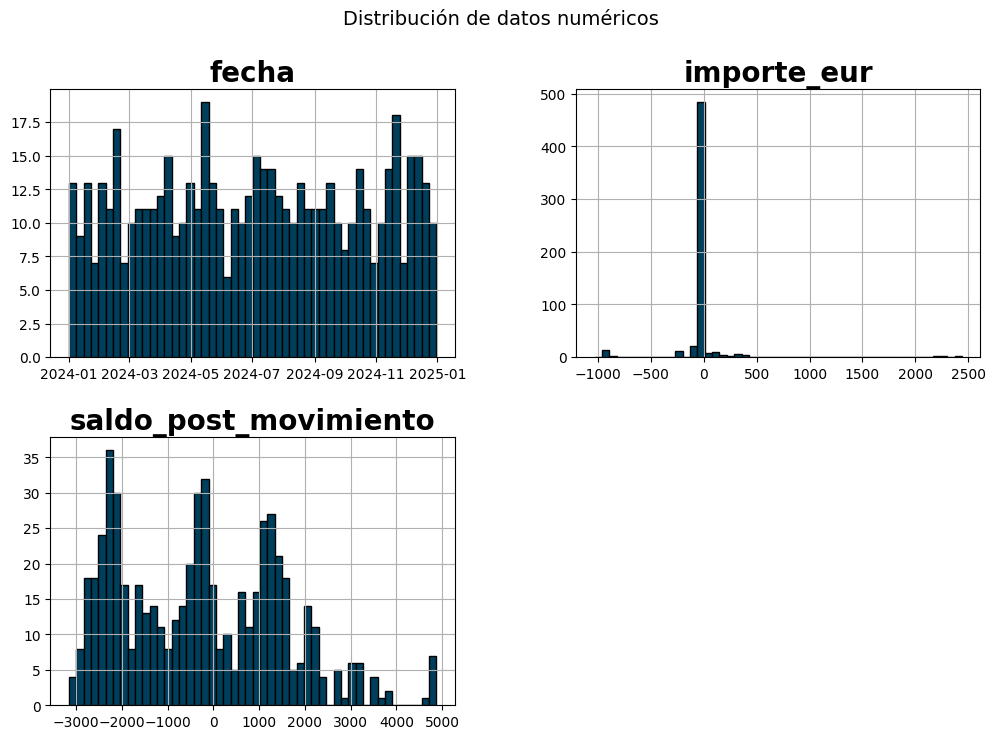

In [13]:
df.hist(figsize=(12,8), bins= 50, edgecolor = "black")
plt.suptitle("Distribución de datos numéricos", fontsize = 14)
plt.ylabel("Cantidad de movimientos")
plt.show()

En el grafico de importe_eur:
* la mayoria de los importes estan cerca del 0
* hay colas largas positivas y negativas
* existen movimientos grandes pocos frecuentes a analizar.


En el saldo_post_movimiento:
* Hay una zona negativa muy notoria
* El saldo negativo ocurre muchas veces
* Presenta alerta de riesgos

### Detección de Outliers

In [14]:
q1 = df["importe_eur"].quantile(0.25)
q3 = df["importe_eur"].quantile(0.75)

iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

# Crear copia explícita para evitar SettingWithCopyWarning y poder modificar el df resultante
outliers_importe = df[
    (df["importe_eur"] < lim_inf) | (df["importe_eur"] > lim_sup)
].copy()

outliers_importe

,fecha,tipo_movimiento,categoria,importe_eur,saldo_post_movimiento,descripcion,canal,mes,dia,alerta,tipo_gasto
0,2024-01-01,Ingreso,Salario,2374.51,4874.51,Nómina mensual,Transferencia,January,Monday,NaN,ingreso de dinero
7,2024-01-04,Ingreso,Bizum,76.83,4760.87,Bizum recibido,Bizum,January,Thursday,NaN,sin definir
8,2024-01-05,Gasto,Alquiler,-900.00,3860.87,Cargo Alquiler,Débito,January,Friday,NaN,fijo
10,2024-01-07,Gasto,Préstamo personal,-220.00,3601.15,Cargo Préstamo personal,Débito,January,Sunday,NaN,fijo
15,2024-01-11,Gasto,Gasto extraordinario,-1033.92,2414.51,Compra excepcional,Tarjeta,January,Thursday,NaN,gasto extraordinario
...,...,...,...,...,...,...,...,...,...,...,...
535,2024-12-05,Gasto,Alquiler,-900.00,-1166.66,Cargo Alquiler,Débito,December,Thursday,Saldo negativo,fijo
539,2024-12-07,Gasto,Préstamo personal,-220.00,-1510.90,Cargo Préstamo personal,Débito,December,Saturday,Saldo negativo,fijo
558,2024-12-16,Ingreso,Bizum,52.68,-2048.14,Bizum recibido,Bizum,December,Monday,Saldo negativo,sin definir
573,2024-12-24,Ingreso,Ingreso extra,390.27,-2196.98,Ingreso puntual,Transferencia,December,Tuesday,Saldo negativo,ingreso de dinero


In [15]:
#ordenar por importe

outliers_importe.sort_values("importe_eur")

,fecha,tipo_movimiento,categoria,importe_eur,saldo_post_movimiento,descripcion,canal,mes,dia,alerta,tipo_gasto
15,2024-01-11,Gasto,Gasto extraordinario,-1033.92,2414.51,Compra excepcional,Tarjeta,January,Thursday,NaN,gasto extraordinario
8,2024-01-05,Gasto,Alquiler,-900.00,3860.87,Cargo Alquiler,Débito,January,Friday,NaN,fijo
96,2024-03-05,Gasto,Alquiler,-900.00,2080.68,Cargo Alquiler,Débito,March,Tuesday,NaN,fijo
51,2024-02-05,Gasto,Alquiler,-900.00,2053.80,Cargo Alquiler,Débito,February,Monday,NaN,fijo
192,2024-05-05,Gasto,Alquiler,-900.00,362.51,Cargo Alquiler,Débito,May,Sunday,NaN,fijo
...,...,...,...,...,...,...,...,...,...,...,...
477,2024-11-01,Ingreso,Salario,2280.93,-625.19,Nómina mensual,Transferencia,November,Friday,Saldo negativo,ingreso de dinero
432,2024-10-01,Ingreso,Salario,2345.26,-814.34,Nómina mensual,Transferencia,October,Tuesday,Saldo negativo,ingreso de dinero
0,2024-01-01,Ingreso,Salario,2374.51,4874.51,Nómina mensual,Transferencia,January,Monday,NaN,ingreso de dinero
188,2024-05-01,Ingreso,Salario,2427.84,2253.35,Nómina mensual,Transferencia,May,Wednesday,NaN,ingreso de dinero


In [16]:
cantidad_gastos_outlies = (outliers_importe["importe_eur"]<0).sum()
print(f'Cantidad de movimientos de gastos altos: {cantidad_gastos_outlies}')

Cantidad de movimientos de gastos altos: 37


In [17]:
cantidad_ingresos_outlies = (outliers_importe["importe_eur"]>0).sum()
print(f'Cantidad de movimientos de ingresos altos: {cantidad_ingresos_outlies}')

Cantidad de movimientos de ingresos altos: 44


Hay mas importes extraordinarios positivos que negativos, tenemos que estudiar si esos importes son de mayor impacto o no sobre el saldo. 

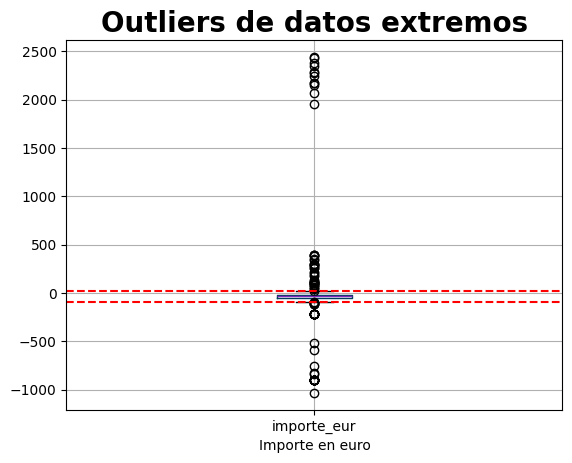

In [18]:
df.boxplot(column="importe_eur")
plt.title("Outliers de datos extremos")
plt.axhline(lim_inf, color="red", linestyle="--")
plt.axhline(lim_sup, color="red", linestyle="--")
plt.xlabel("Importe en euro")
plt.show()


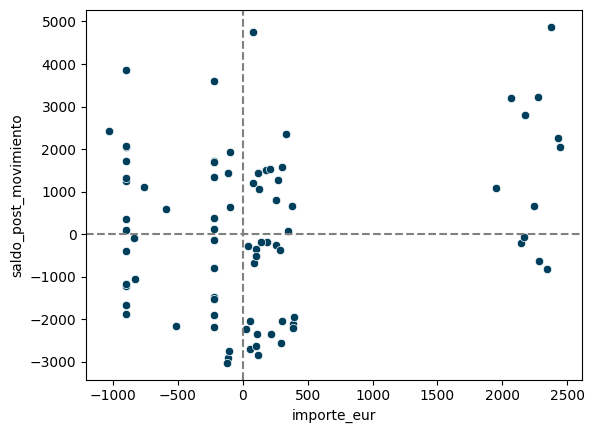

In [19]:
sns.scatterplot(
    data=outliers_importe,
    x="importe_eur",
    y="saldo_post_movimiento"
)
plt.axvline(0, color="grey", linestyle="--")
plt.axhline(0, color="grey", linestyle="--")
plt.show()


In [20]:
# Asignación usando .loc para evitar SettingWithCopyWarning
outliers_importe.loc[:, "signo"] = np.where(outliers_importe["importe_eur"] > 0, "Ingreso extremo", "Gasto extremo")

outliers_importe.groupby("signo")["saldo_post_movimiento"].agg(
    promedio="mean",
    mediana="median",
    minimo="min",
    maximo="max",
    cantidad="count"
).round(2)

,promedio,mediana,minimo,maximo,cantidad
signo,,,,,
Gasto extremo,93.95,116.34,-3019.71,3860.87,37
Ingreso extremo,136.67,-178.36,-2836.29,4874.51,44


Vemos que cuando el cliente a pesar de tener un gasto grande, por tener anteriormente una cantidad de saldo considerable, en promedio termina en positivo. Esto quiere decir que al momento de tener ese gasto, el cliente era conciente del dinero que disponia.
Pero a pesar de tener ingresos grandes, tambien presenta momentos donde el saldo lo tiene en negativo por lo que hay en un momento de su saldo, que no pudo saldar los gastos grandes.

In [21]:
outliers_importe["descripcion"].unique()

<StringArray>
[         'Nómina mensual',          'Bizum recibido',
          'Cargo Alquiler', 'Cargo Préstamo personal',
      'Compra excepcional',         'Ingreso puntual',
           'Bizum enviado']
Length: 7, dtype: str

In [22]:
outliers_importe[outliers_importe["descripcion"]== "Compra excepcional"]

,fecha,tipo_movimiento,categoria,importe_eur,saldo_post_movimiento,descripcion,canal,mes,dia,alerta,tipo_gasto,signo
15,2024-01-11,Gasto,Gasto extraordinario,-1033.92,2414.51,Compra excepcional,Tarjeta,January,Thursday,NaN,gasto extraordinario,Gasto extremo
30,2024-01-20,Gasto,Gasto extraordinario,-759.67,1120.75,Compra excepcional,Tarjeta,January,Saturday,NaN,gasto extraordinario,Gasto extremo
177,2024-04-25,Gasto,Gasto extraordinario,-838.60,-77.99,Compra excepcional,Tarjeta,April,Thursday,Saldo negativo,gasto extraordinario,Gasto extremo
191,2024-05-03,Gasto,Gasto extraordinario,-897.18,1262.51,Compra excepcional,Tarjeta,May,Friday,NaN,gasto extraordinario,Gasto extremo
294,2024-07-06,Gasto,Gasto extraordinario,-593.82,591.62,Compra excepcional,Tarjeta,July,Saturday,NaN,gasto extraordinario,Gasto extremo
322,2024-07-20,Gasto,Gasto extraordinario,-829.57,-1041.46,Compra excepcional,Tarjeta,July,Saturday,Saldo negativo,gasto extraordinario,Gasto extremo
403,2024-09-10,Gasto,Gasto extraordinario,-517.08,-2159.11,Compra excepcional,Tarjeta,September,Tuesday,Saldo negativo,gasto extraordinario,Gasto extremo


In [23]:
sumatoria_compra_excepcional = round(outliers_importe[outliers_importe["descripcion"]== "Compra excepcional"]["importe_eur"].sum(),2)

print(f'La sumatoria de los cargos excepcionales es de:  {sumatoria_compra_excepcional}€')

La sumatoria de los cargos excepcionales es de:  -5469.84€


Presenta varios cargos excepcionales. Los cuales los mas preocupantes son cuando su saldo pasa a ser negativo.

In [24]:
gastos_fijos = outliers_importe.groupby("tipo_gasto")["importe_eur"].sum()
gastos_fijos

tipo_gasto
fijo                   -13440.00
gasto extraordinario    -5469.84
ingreso de dinero       32490.09
sin definir                60.73
Name: importe_eur, dtype: float64

In [25]:
f"El cliente presenta gastos fijos durante el año de: {gastos_fijos.fijo.sum()} €"

'El cliente presenta gastos fijos durante el año de: -13440.0 €'

### Análisis categoria

In [26]:
#Vemos la cantidad de movimientos de gastos por categoria
categoria_gasto = df[df["importe_eur"]<0]["categoria"].value_counts().reset_index()
categoria_gasto

,categoria,count
0,Alimentación,141
1,Transporte,79
2,Restaurantes,54
3,Ocio,38
4,Otros,36
5,Ropa,28
6,Salud,28
7,Bizum,16
8,Educación,13
9,Alquiler,12


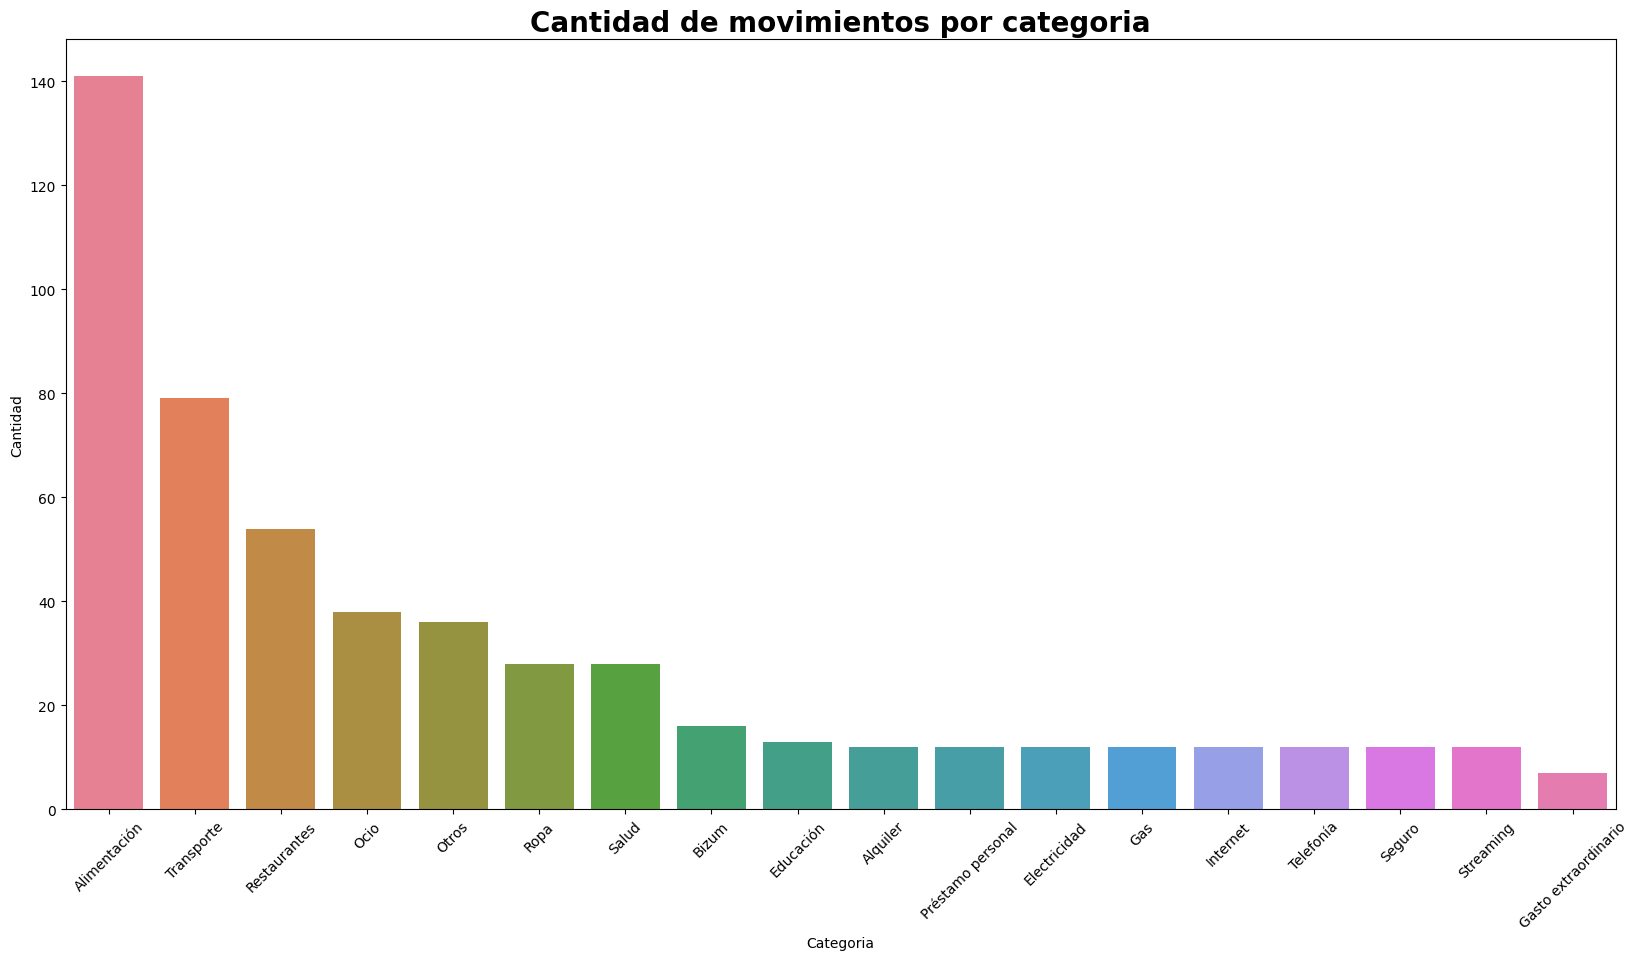

In [27]:
plt.figure(figsize = (20,10))
sns.barplot(data=categoria_gasto,x="categoria", y="count", hue="categoria")
plt.title("Cantidad de movimientos por categoria")
plt.xlabel("Categoria")
plt.ylabel("Cantidad")
plt.xticks(rotation= 45)
plt.show()

Vemos que hay una amplia diferecia con respecto a la alimentación en la cantidad de movimientos en los gastos.
Esto muestra cantidad de movimientos, no representa monetariamente.

In [28]:
#obtener top por gasto absoluto y ordenar de mayor a menor
gasto_por_categoria = df[df["importe_eur"]<0].groupby("categoria")["importe_eur"].sum().abs().sort_values(ascending=False).reset_index()
top5_gasto_personal = gasto_por_categoria.head(5)

TOP 5 de gastos durante el año.

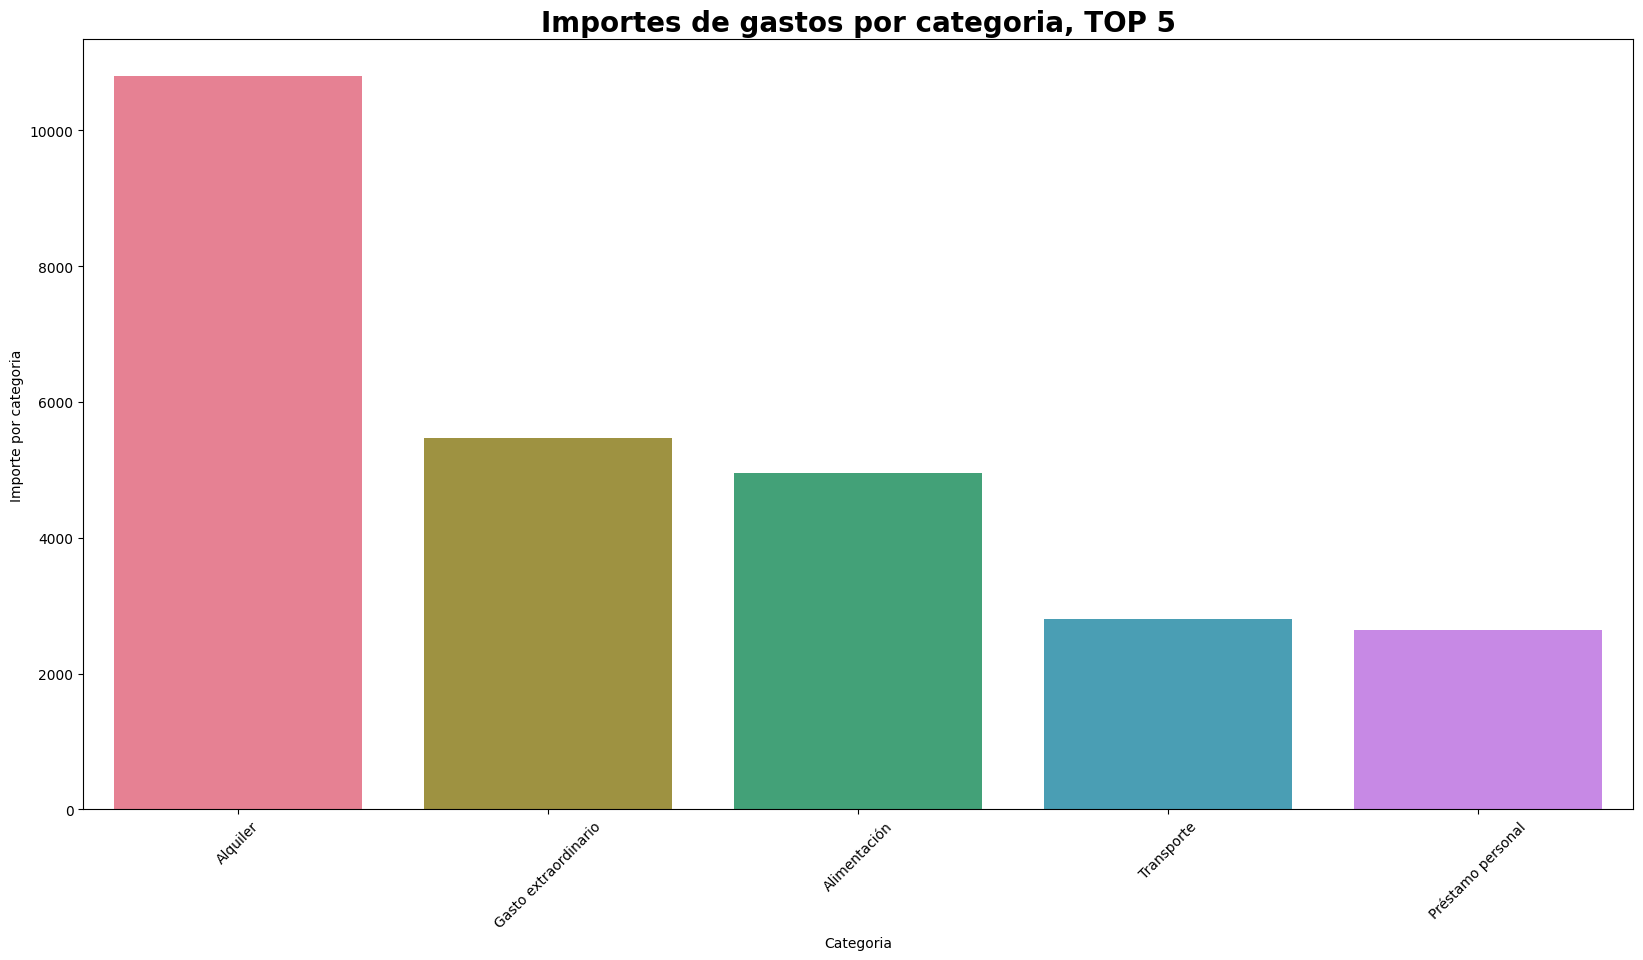

In [29]:
plt.figure(figsize=(20,10))
sns.barplot(data=top5_gasto_personal, x="categoria", y="importe_eur", hue="categoria")
plt.title("Importes de gastos por categoria, TOP 5")
plt.xlabel("Categoria")
plt.ylabel("Importe por categoria")
plt.xticks(rotation=45)
plt.show()

Top 5 de las categorias que más gastos generan, algunos son gastos fijos y otros variables.

### Análisis por mes

In [30]:
#agrupamos unicamente los gastos por mes.

gastos_por_mes = df[df["importe_eur"]<0].groupby("mes")["importe_eur"].sum().abs()


#agrupamos unicamente los ingresos por mes
ingresos_por_mes = df[df["importe_eur"]>0].groupby("mes")["importe_eur"].sum()

#creamos un dataframe con los gastos e ingresos
resumen_mensual = pd.DataFrame({
    "gastos": gastos_por_mes,
    "ingresos": ingresos_por_mes
})

#creamos un melt, para poder graficar luego un barplot donde compare cada mes y sea mas facil visualmente.
resumen_mensual = (
    resumen_mensual.reset_index().melt(
        id_vars="mes",
        value_vars=["gastos","ingresos"],
        var_name="tipo",
        value_name="monto"
    )
)

sorted(resumen_mensual["mes"])
resumen_mensual

,mes,tipo,monto
0,January,gastos,4289.92
1,February,gastos,2673.04
2,March,gastos,2936.36
3,April,gastos,3470.69
4,May,gastos,3789.75
5,June,gastos,2112.87
6,July,gastos,4355.99
7,August,gastos,3030.26
8,September,gastos,3116.63
9,October,gastos,2498.79


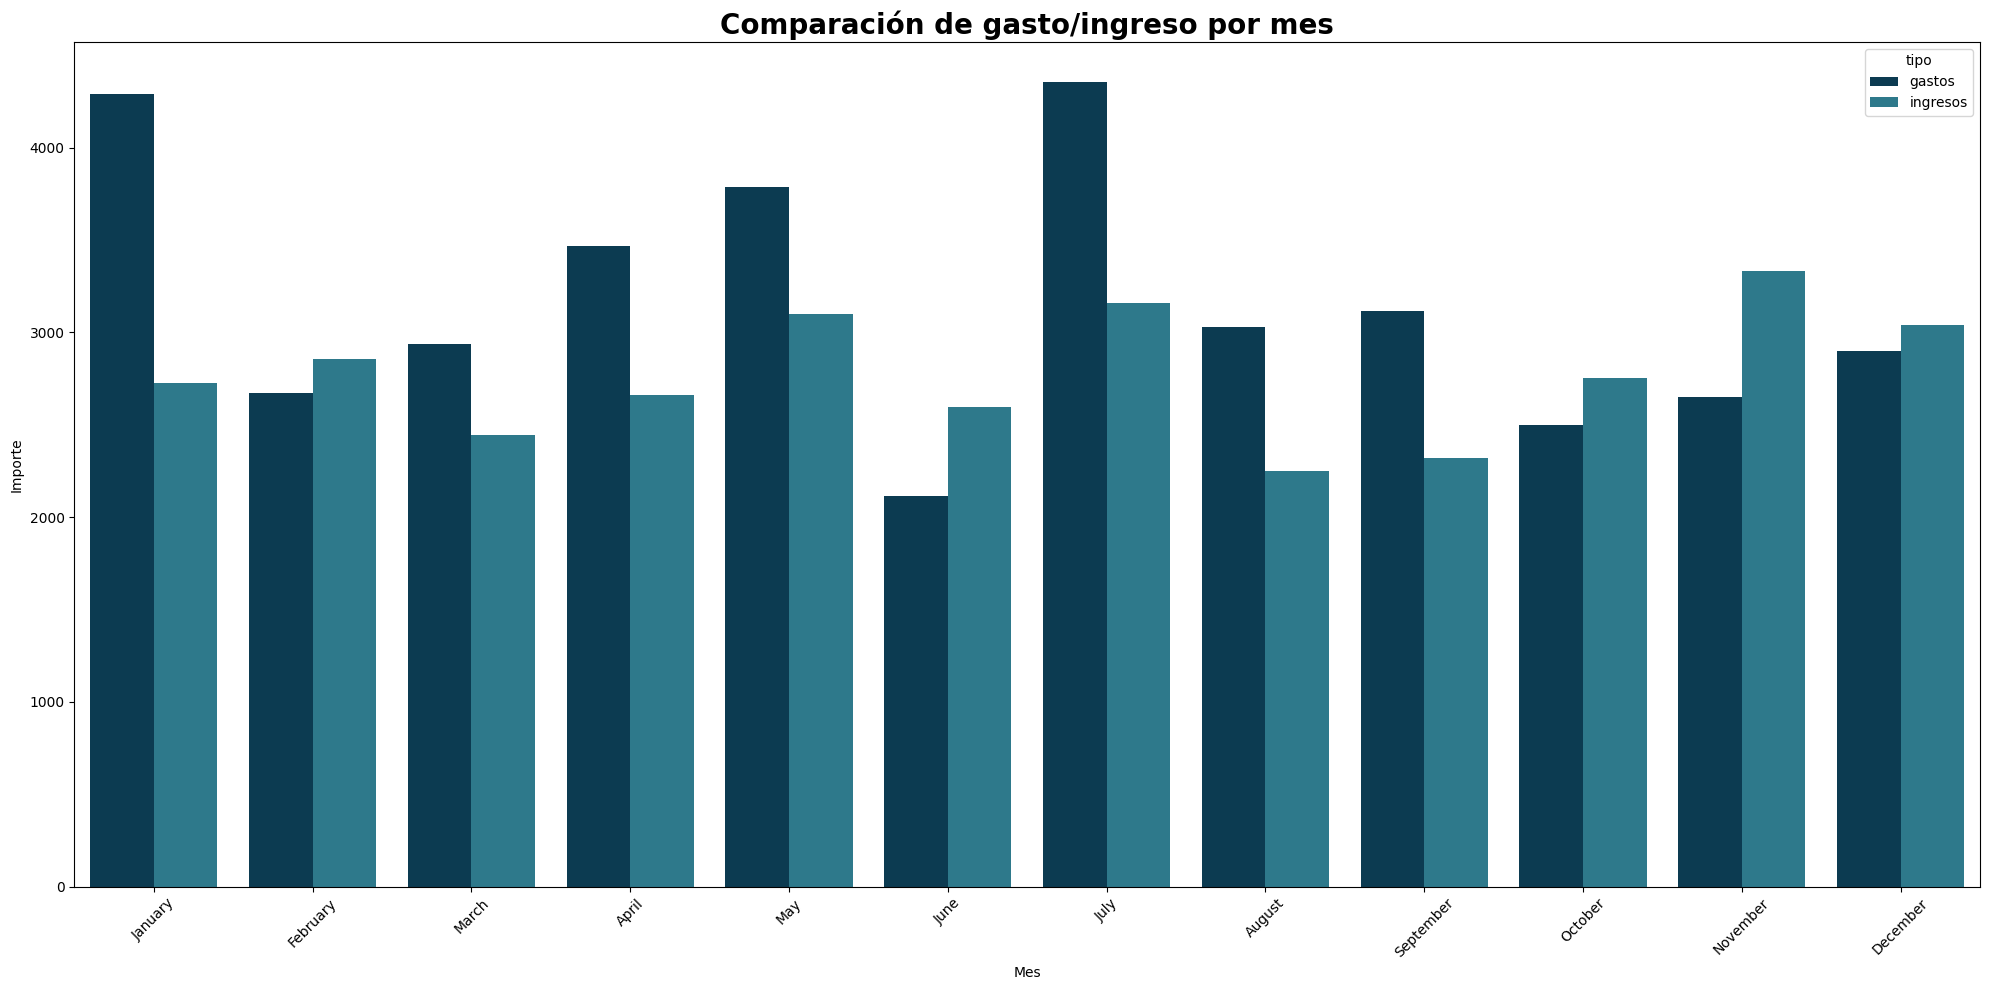

In [31]:
plt.figure(figsize=(20,10))
sns.barplot(data=resumen_mensual, x="mes", y="monto", hue="tipo")
plt.title("Comparación de gasto/ingreso por mes")
plt.xlabel("Mes")
plt.ylabel("Importe")
plt.xticks(rotation= 45)
plt.tight_layout()
plt.show()


Vemos una clara tendencia de gastar más de lo que ingresa, por lo que el ahorro se dificulta.
Sin embargo, hay una tendencia creciente a partir del mes de octubre sobre lo que ingresa a comparación de los gastos. Es un periodo de tiempo a analizar, por que se debe esa bajada en los gastos?

In [32]:
#Quiero investigar como queda el saldo de la cuenta al finalizar cada mes.

mes_post = df.groupby("mes", observed=True)["saldo_post_movimiento"].last().reset_index()
sorted(mes_post)
mes_post

,mes,saldo_post_movimiento
0,January,936.50
1,February,1122.51
2,March,632.83
3,April,-174.49
4,May,-866.75
5,June,-381.03
6,July,-1579.89
7,August,-2361.59
8,September,-3159.60
9,October,-2906.13


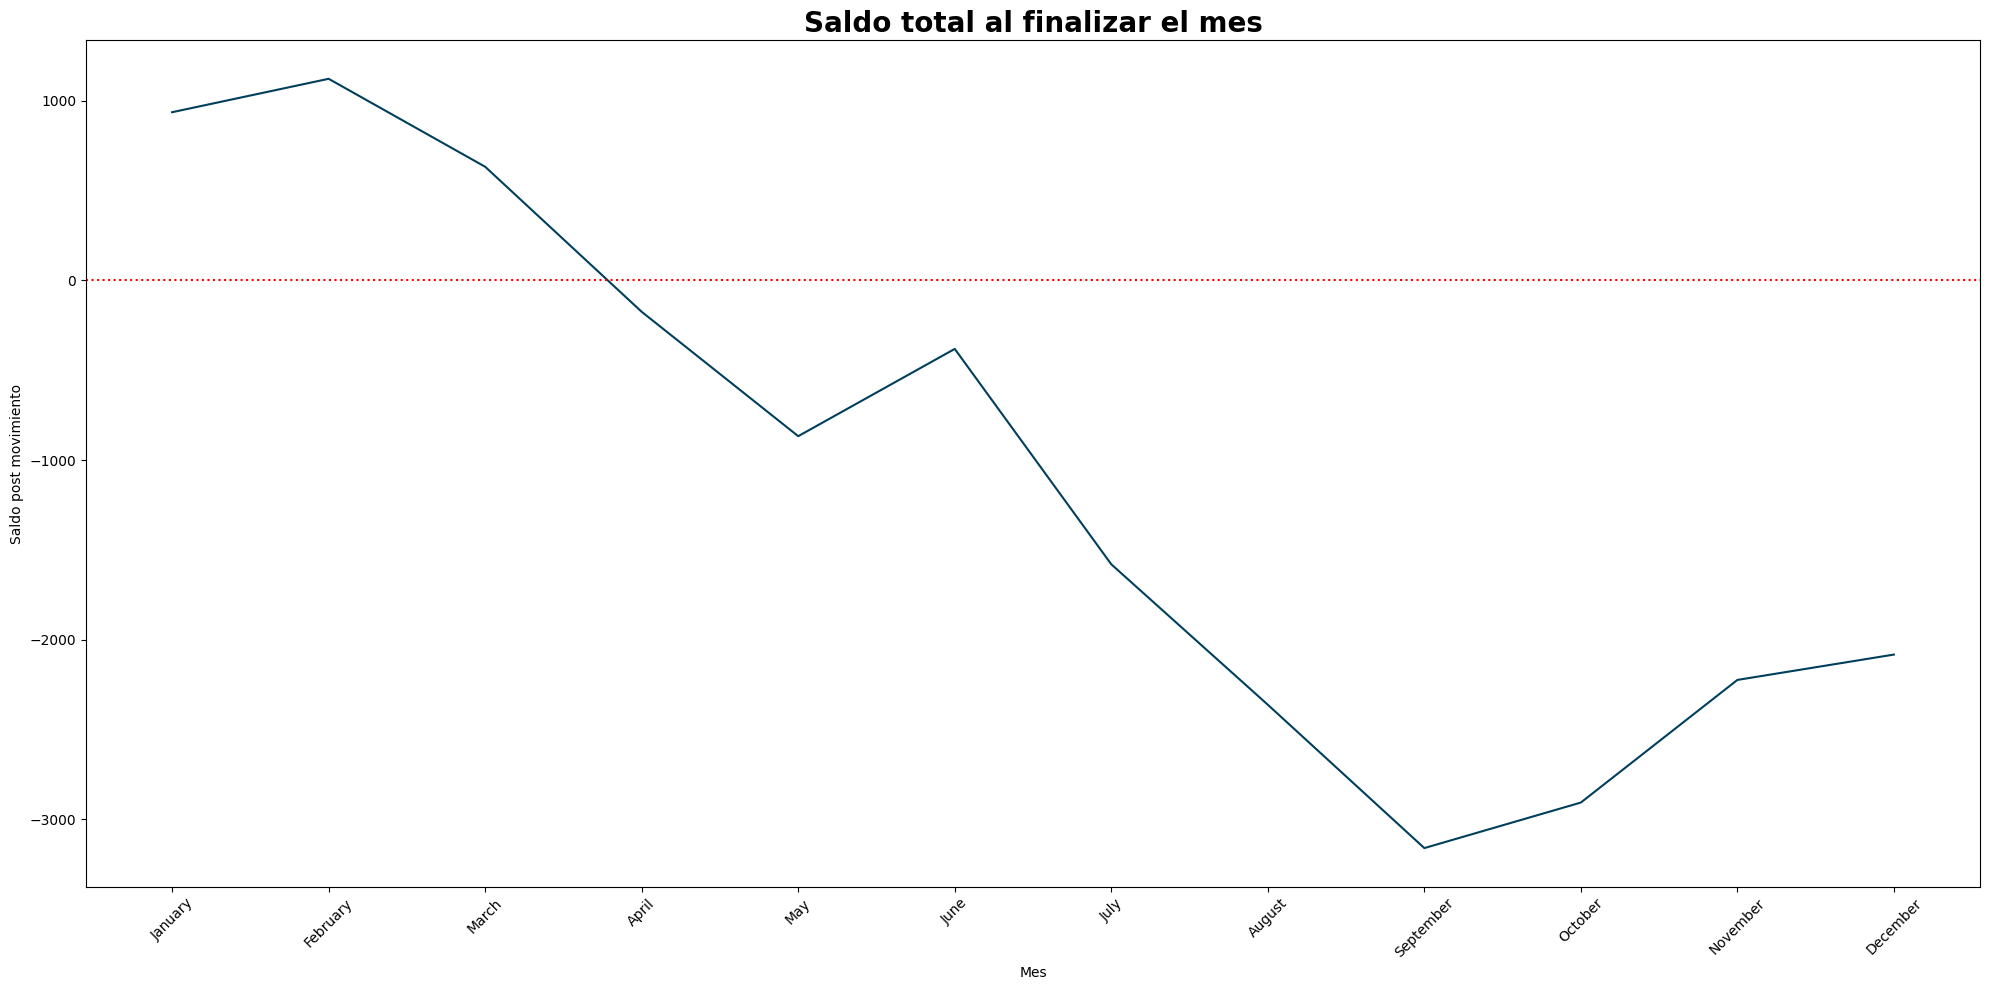

In [33]:
plt.figure(figsize=(20,10))
sns.lineplot(data= mes_post, x= "mes", y= "saldo_post_movimiento")
plt.xlabel("Mes")
plt.ylabel("Saldo post movimiento")
plt.title("Saldo total al finalizar el mes")
plt.axhline(color="red", linestyle= ':' )
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Vemos una clara descendencia del salario al finalizar cada mes. Hay un ligero repunte en el mes de junio que luego vuelve a caer.
A partir de Septiembre, comienza un nuevo crecimiento del saldo.
Hay que analizar los gastos por categorias desde junio a septiembre para saber por que baja mucho el saldo y no logra repuntar, que tipos de gastos se hizo? 
Luego en septiembre se vio un repunte hacia arriba? por que se debe esto? que gasto no se esta haciendo? puede ser la finalizacion de un prestamo? o ha ingresado mas dinero de lo habitual?

In [34]:
#Se crea un dataframe que agrupe por mes, con las columnas definidos en ingresos, gastos y saldo final. Se chequea lo que se ingreso por mes y lo que se gasto, para sacar la diferencia.

df_mes_ingreso_y_gasto = df.groupby("mes").agg(
    ingresos=("importe_eur", lambda x: x[x>0].sum()),
    gastos=("importe_eur", lambda x: x[x<0].sum()),
    saldo_final=("saldo_post_movimiento", "last")
)


df_mes_ingreso_y_gasto



,ingresos,gastos,saldo_final
mes,,,
January,2726.40,-4289.92,936.50
February,2859.07,-2673.04,1122.51
March,2446.67,-2936.36,632.83
April,2663.34,-3470.69,-174.49
May,3097.48,-3789.75,-866.75
June,2598.59,-2112.87,-381.03
July,3157.15,-4355.99,-1579.89
August,2248.55,-3030.26,-2361.59
September,2318.62,-3116.63,-3159.60


In [35]:
#saco la diferencia de ingresos y gastos (es una suma ya que los gastos aparecen en negativos)

df_diferencia = df_mes_ingreso_y_gasto["ingresos"] + df_mes_ingreso_y_gasto["gastos"]
df_diferencia = df_diferencia.reset_index(name="Diferencia ingreso - gasto")
df_diferencia

,mes,Diferencia ingreso - gasto
0,January,-1563.52
1,February,186.03
2,March,-489.69
3,April,-807.35
4,May,-692.27
5,June,485.72
6,July,-1198.84
7,August,-781.71
8,September,-798.01
9,October,253.49


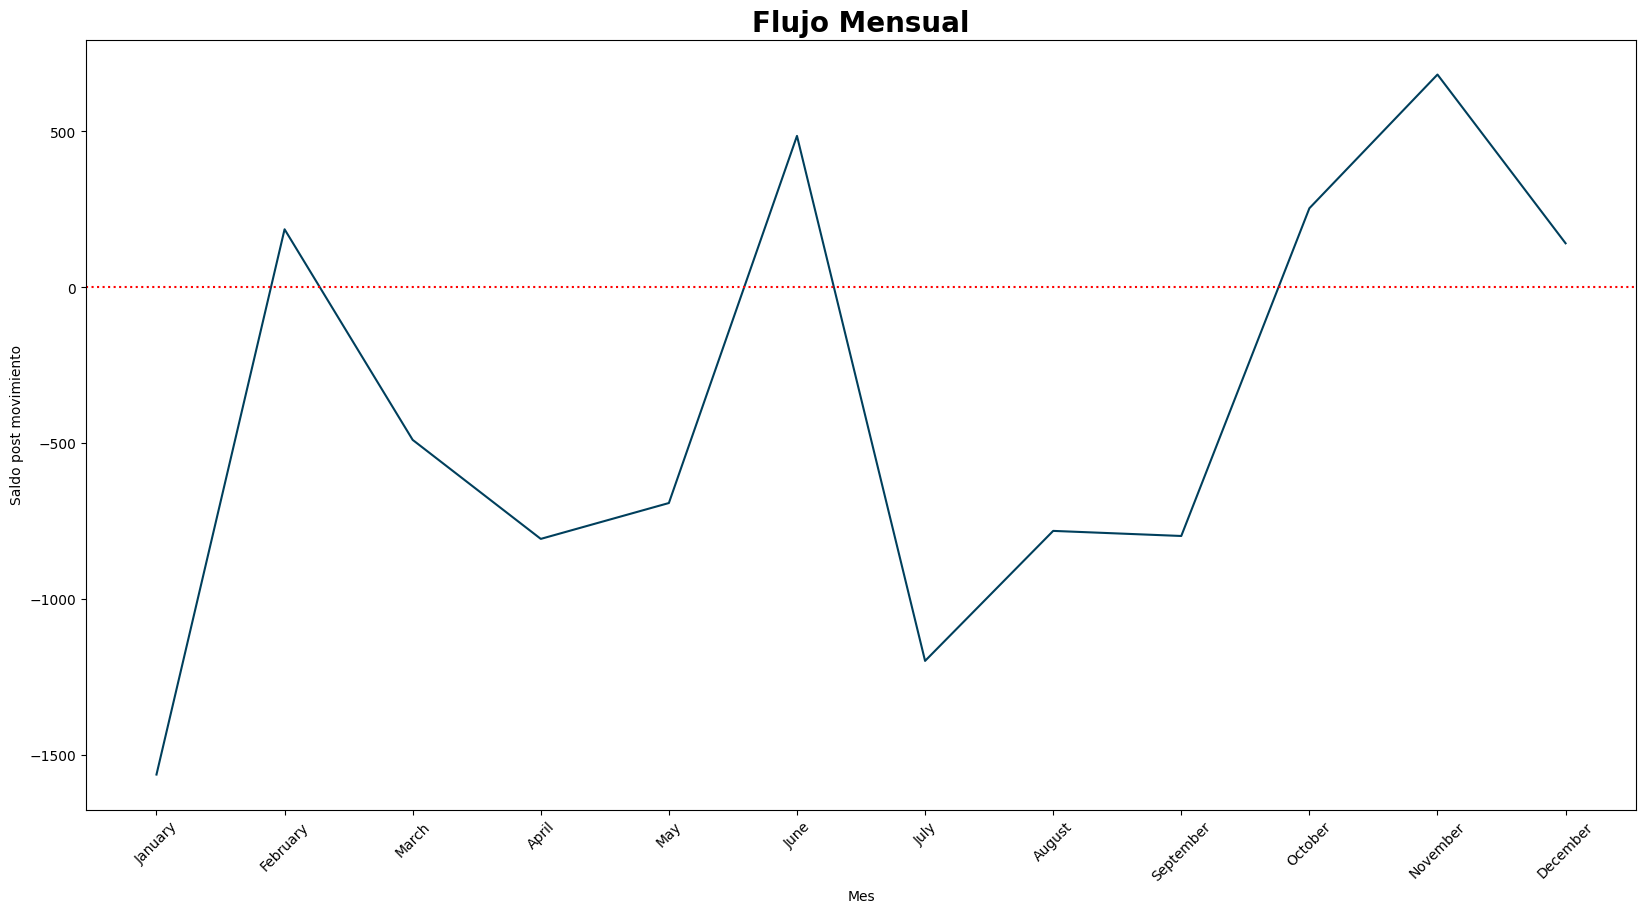

In [36]:
plt.figure(figsize=(20,10))
sns.lineplot(data= df_diferencia, x= "mes", y= "Diferencia ingreso - gasto")
plt.xlabel("Mes")
plt.ylabel("Saldo post movimiento")
plt.title("Flujo Mensual")
plt.axhline(color= "red", linestyle= ":")
plt.xticks(rotation = 45)
plt.show()

Vemos que el cliente tiene varios repuntes de su saldo, donde enero y julio son los meses que peor caida presente. Hay que averiguar que categoria es la culpable en estos 2 meses para saber donde poder interferir para mejorar su ahorro

1. ¿Qué porcentaje de mis ingresos se va a cada categoría de gasto y cómo ha evolucionado mes a mes?

In [37]:
# Creo un dataframe de ingresos, recogiendo los datos unicamente de ingresos_por_mes, modificando la columna import_eur a ingresos.
ingresos = pd.DataFrame(ingresos_por_mes).reset_index().rename(columns={"importe_eur":"ingresos"})
ingresos

,mes,ingresos
0,January,2726.40
1,February,2859.07
2,March,2446.67
3,April,2663.34
4,May,3097.48
5,June,2598.59
6,July,3157.15
7,August,2248.55
8,September,2318.62
9,October,2752.28


In [38]:
gastos_por_mes

mes
January      4289.92
February     2673.04
March        2936.36
April        3470.69
May          3789.75
June         2112.87
July         4355.99
August       3030.26
September    3116.63
October      2498.79
November     2649.45
December     2899.48
Name: importe_eur, dtype: float64

In [39]:
#Corroboro la cantidad en dinero de gastos por categoria. Modificamos el nombre de la columna importe_eur en gastos para mejor definición

gastos_cat_por_mes = df[df["importe_eur"]<0].groupby(["categoria","mes"])["importe_eur"].sum().reset_index().rename(columns={"importe_eur":"gastos"})
gastos_cat_por_mes = pd.DataFrame(gastos_cat_por_mes)
gastos_cat_por_mes

,categoria,mes,gastos
0,Alimentación,January,-355.83
1,Alimentación,February,-333.02
2,Alimentación,March,-435.51
3,Alimentación,April,-341.90
4,Alimentación,May,-298.83
...,...,...,...
193,Transporte,August,-250.14
194,Transporte,September,-169.48
195,Transporte,October,-134.88
196,Transporte,November,-239.09


In [40]:
#Uno los 2 dataframe para tener una mejor visualización de los datos
ingr_gas_por_mes = pd.merge(ingresos, gastos_cat_por_mes, how="inner", on="mes")

ingr_gas_por_mes

,mes,ingresos,categoria,gastos
0,January,2726.4,Alimentación,-355.83
1,January,2726.4,Alquiler,-900.00
2,January,2726.4,Educación,-99.63
3,January,2726.4,Electricidad,-70.00
4,January,2726.4,Gas,-45.00
...,...,...,...,...
193,December,3040.6,Salud,-52.59
194,December,3040.6,Seguro,-45.00
195,December,3040.6,Streaming,-25.00
196,December,3040.6,Telefonía,-35.00


In [41]:
#Se crea una columna con el nombre de porcentaje. Muestra el porcentaje que representa por mes, los gastos de la categoria sobre sus ingresos.
if ingr_gas_por_mes["ingresos"].any() != 0:
    ingr_gas_por_mes["porcentaje"] = round((ingr_gas_por_mes["gastos"] / ingr_gas_por_mes["ingresos"]) * 100, 2).abs()

ingr_gas_por_mes

,mes,ingresos,categoria,gastos,porcentaje
0,January,2726.4,Alimentación,-355.83,13.05
1,January,2726.4,Alquiler,-900.00,33.01
2,January,2726.4,Educación,-99.63,3.65
3,January,2726.4,Electricidad,-70.00,2.57
4,January,2726.4,Gas,-45.00,1.65
...,...,...,...,...,...
193,December,3040.6,Salud,-52.59,1.73
194,December,3040.6,Seguro,-45.00,1.48
195,December,3040.6,Streaming,-25.00,0.82
196,December,3040.6,Telefonía,-35.00,1.15


In [42]:
#Se realiza un TOP 5 de los porcentajes de gastos que mas influyen sobre los ingresos

#top de categoria que mas influye
top_categoria_porcentaje = ingr_gas_por_mes.groupby("categoria")["porcentaje"].mean().sort_values(ascending=False).head(5).index


#si integra el top de categoria que lo agregue al df
df_plot = ingr_gas_por_mes[ingr_gas_por_mes["categoria"].isin(top_categoria_porcentaje)]
df_plot

,mes,ingresos,categoria,gastos,porcentaje
0,January,2726.40,Alimentación,-355.83,13.05
1,January,2726.40,Alquiler,-900.00,33.01
5,January,2726.40,Gasto extraordinario,-1793.59,65.79
9,January,2726.40,Préstamo personal,-220.00,8.07
15,January,2726.40,Transporte,-218.91,8.03
16,February,2859.07,Alimentación,-333.02,11.65
17,February,2859.07,Alquiler,-900.00,31.48
25,February,2859.07,Préstamo personal,-220.00,7.69
32,February,2859.07,Transporte,-164.69,5.76
33,March,2446.67,Alimentación,-435.51,17.80


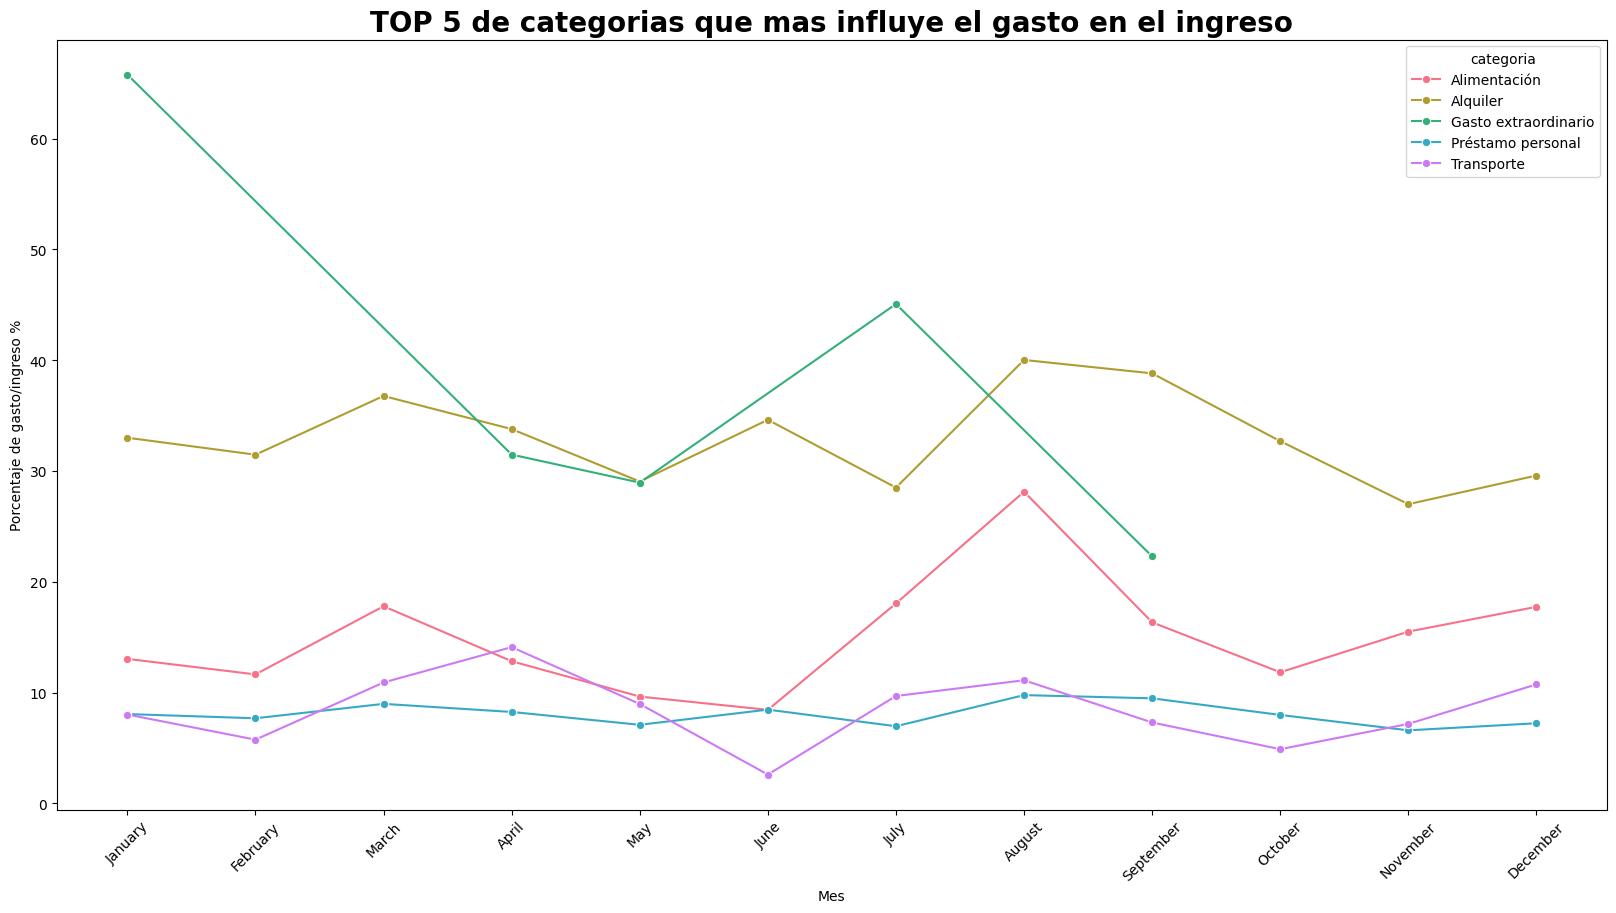

In [43]:
plt.figure(figsize=(20,10))
sns.lineplot(data=df_plot, x="mes", y="porcentaje",hue="categoria", marker="o")
plt.title("TOP 5 de categorias que mas influye el gasto en el ingreso")
plt.xlabel("Mes")
plt.ylabel("Porcentaje de gasto/ingreso %")
plt.xticks(rotation=45)
plt.show()

El gráfico muestra que los picos en el porcentaje del ingreso destinado a gastos se producen principalmente en los meses en los que aparecen gastos extraordinarios.
Estos eventos generan el mayor impacto negativo sobre el saldo mensual, debido a su carácter puntual y no recurrente.

En contraste, el alquiler representa de forma consistente el mayor porcentaje del gasto mensual; sin embargo, su impacto es estructural y previsible, ya que se trata de un gasto fijo.

La alimentación corresponde a un gasto recurrente, aunque se observa un incremento significativo en el mes de agosto. Este aumento podría estar asociado a factores estacionales, como vacaciones, mayor consumo fuera del hogar o gastos extraordinarios vinculados al período.

Por último, el préstamo personal y el transporte presentan una evolución relativamente lineal, lo que indica que su porcentaje sobre el ingreso se mantiene estable a lo largo del tiempo y no genera desequilibrios significativos en el presupuesto mensual.

### Gasto acumulativo por tipo_gasto

In [44]:
#agrupo tipo gasto y su cantidad de importe

df_tipo_gasto = df.groupby("tipo_gasto")["importe_eur"].sum().reset_index()
df_tipo_gasto

,tipo_gasto,importe_eur
0,fijo,-17106.72
1,gasto extraordinario,-10813.90
2,gasto recurrente,-8783.31
3,ingreso de dinero,32490.09
4,sin definir,-368.63


### Gasto en Alimentación

In [45]:
gasto_alimentacion = df[df["categoria"] == "Alimentación"].groupby("dia")["importe_eur"].sum().reset_index()
gasto_alimentacion.sort_values(by="importe_eur")

,dia,importe_eur
5,Tuesday,-865.07
2,Saturday,-834.27
0,Friday,-729.24
3,Sunday,-692.88
1,Monday,-636.46
4,Thursday,-613.22
6,Wednesday,-577.30


In [49]:
media_alimentacion = pd.Series([gasto_alimentacion["importe_eur"].min(), gasto_alimentacion["importe_eur"].max()]).mean()

print(f'La media de gasto entre el maximo y el minimo de lo gastado en alimentación es: {media_alimentacion}')



La media de gasto entre el maximo y el minimo de lo gastado en alimentación es: -721.185


In [47]:
gasto_alimentacion["porcentaje_a_ahorrar"] = round(((gasto_alimentacion["importe_eur"] - media_alimentacion)/gasto_alimentacion["importe_eur"]) * 100, 2)
gasto_alimentacion

,dia,importe_eur,porcentaje_a_ahorrar
0,Friday,-729.24,1.10
1,Monday,-636.46,-13.31
2,Saturday,-834.27,13.55
3,Sunday,-692.88,-4.09
4,Thursday,-613.22,-17.61
5,Tuesday,-865.07,16.63
6,Wednesday,-577.30,-24.92


Los martes y los sabados, son los dias que más gasta a comparación de la media a gastar. Entre un 13% y 16%.

2. ¿Hay meses con el mismo nivel de ingresos pero distintos niveles de saldo final? ¿A qué categorías se debe la diferencia?

In [48]:
media_ingresos = round(ingresos["ingresos"].mean(),2)
f"La media de los ingresos ronda los {media_ingresos}"

'La media de los ingresos ronda los 2770.06'

De enero a septiembre vemos que presenta gastos extraordinarios, los cuales modifican sustenciamente el saldo a fin de mes. Podemos comprobar que a partir de que el cliente no tiene mas esos gastos, el saldo final sube levemente. Hay que tener en cuenta que los gastos arastraron una baja sustencial mes a mes por lo que es ese el motivo del crecimiento de forma leve. 

3. ¿Hay meses con ‘picos’ de gasto que ponen en riesgo mantener un saldo mínimo de seguridad?

de Enero a Septiembre son los meses que perjudicaron el saldo del cliente.

### Pregunta de negocio

* ¿Cómo puedo optimizar mi estructura de gastos para aumentar mi ahorro mensual sin reducir en exceso mi calidad de vida?

Podemos afirmar que el cliente tuvo una caida notoria de su saldo debido a gastos extraordinarios que afectaron el ahorro mensual. Eran gastos que se generaban en un momento donde el cliente no disponia de ese dinero, por lo que por eso llega a negativo, presentando una preocupante situacion. 
La manera de optimizar la estructura de gastos seria, no gastar mas de lo que tengo.
Por lo que proponemos unas Acciones concretas a relizar:

- (1)Reducir 